In [1]:
# EV availability MCMC – Reproducing survey-based profiles

"""
This module implements the Markov-Chain Monte Carlo (MCMC) framework for
electric-vehicle (EV) plug-in availability described in Bucksteeg et al. (2026)
("Is it plugged in? Impact of Vehicle-to-grid and the Connecting
Behavior on the European Power System")

Core idea:
- Use an online survey of EV owners to obtain empirical distributions of
  battery capacity and willingness to share battery capacity with the grid
- Use observed hourly connection patterns (weekdays vs. weekends) to build
  time-inhomogeneous two-state Markov chains ("connected" vs "disconnected")
- Simulate large sets of daily plug-in trajectories via MCMC and combine
  them with sampled capacities and willingness to share to obtain
  availability and control-potential profiles for a future EV fleet

The resulting profiles can be used as input for long-term energy system
models such as E2M2s to quantify how realistic plug-in behavior affects
renewable integration, generation adequacy, system costs, and the value
of vehicle-to-grid (V2G) operation

Assumptions and data basis (short summary):
- Survey working sample: 260 EV owners after quality checks and removal
  of outliers and implausible responses
- Average battery capacity is around 55 kWh; the median is close to 56 kWh
- On average, participants are willing to provide roughly 44% of their
  battery capacity for grid services, with substantial heterogeneity
- Plug-in probabilities on a typical weekday peak around the late evening
  with values clearly below 30%, and are lower during the day, reflecting
  commuter-style behavior

See the paer for system-level results and the corresponding methods chapter 
for methodological details:
- DOI: [...]
"""

'\nThis module implements the Markov-Chain Monte Carlo (MCMC) framework for\nelectric-vehicle (EV) plug-in availability described in Bucksteeg et al. (2026)\n("Is it plugged in? Impact of Vehicle-to-grid and the Connecting\nBehavior on the European Power System")\n\nCore idea:\n- Use an online survey of EV owners to obtain empirical distributions of\n  battery capacity and willingness to share battery capacity with the grid\n- Use observed hourly connection patterns (weekdays vs. weekends) to build\n  time-inhomogeneous two-state Markov chains ("connected" vs "disconnected")\n- Simulate large sets of daily plug-in trajectories via MCMC and combine\n  them with sampled capacities and willingness to share to obtain\n  availability and control-potential profiles for a future EV fleet\n\nThe resulting profiles can be used as input for long-term energy system\nmodels such as E2M2s to quantify how realistic plug-in behavior affects\nrenewable integration, generation adequacy, system costs, a

In [2]:
# 1) Imports and base paths
# Loads all required Python packages and defines the directory structure; RAW_SURVEY_PATH points to the anonymised EV survey data used to construct empirical plug-in probabilities and to calibrate the Markov-chain availability model

from __future__ import annotations

#Standard library imports
from dataclasses import dataclass
from pathlib import Path
from typing import List

#Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.colors import to_rgb

# Base paths: the notebook directory is used as working directory and the survey CSV is expected in the same folder (can be adapted if needed)
BASE_DIR = Path(".").resolve()
RAW_SURVEY_PATH = BASE_DIR / "raw_data_surveyV2G.csv"

print("Using base directory:", BASE_DIR)
print("Using raw survey file:", RAW_SURVEY_PATH)

Using base directory: C:\Users\delic\Desktop\GitHub_V2G_E2M2s_MCMC_v2\MCMC
Using raw survey file: C:\Users\delic\Desktop\GitHub_V2G_E2M2s_MCMC_v2\MCMC\raw_data_surveyV2G.csv


In [3]:
# 2) Data container for cleaned EV survey inputs
# Stores cleaned EV survey inputs that serve as the empirical basis for the V2G availability analysis and the Markov-chain Monte Carlo model

@dataclass
class EVSurveyData:
    """
    Container for cleaned survey-based EV input data

    Attributes
    ----------
    battery_capacity_kwh :
        Individual EV battery capacities in kWh
    battery_share_percent :
        Percentage of battery capacity that respondents are willing to
        make available for grid services (0–100)
    connection_week :
        Hourly weekday connection states (0/1) per respondent
    connection_weekend :
        Hourly weekend connection states (0/1) per respondent

    Conceptual role
    ---------------
    The survey data provide the empirical foundation for the behavioral
    MCMC model

    - Capacities and willingness-to-share are sampled from smoothed
      distributions to create synthetic EV parameters
    - Hourly connection profiles are used to estimate time-varying
      two-state transition matrices, capturing realistic arrival and
      departure patterns over the day
    """

    battery_capacity_kwh: np.ndarray
    battery_share_percent: np.ndarray
    connection_week: np.ndarray
    connection_weekend: np.ndarray

    @property
    def battery_share_fraction(self) -> np.ndarray:
        """Willingness-to-share values converted to fractions in [0, 1]"""
        return self.battery_share_percent / 100.0

In [4]:
# 3) Build input tables from the raw EV survey CSV
# Reads the anonymised EV survey file, applies the working-sample filter, constructs input tables for battery capacity, willingness-to-share, weekday and weekend connection profiles, and price premia, and bundles them in an EVSurveyData object used as input to the MCMC and availability analysis

def parse_numeric(series: pd.Series) -> pd.Series:
    """
    Robust numeric parser for survey columns

    - removes percent signs
    - converts German decimal commas to dots
    - strips whitespace
    - returns float with NaN for non-parsable entries
    """
    return pd.to_numeric(
        series.astype(str)
              .str.replace("%", "", regex=False)
              .str.replace(",", ".", regex=False)
              .str.strip(),
        errors="coerce",
    )

def build_input_tables_from_raw(raw_path: Path):
    """
    Load the raw EV survey CSV and construct structured input tables
    for the availability and MCMC analysis

    Generated tables
    ----------------
    - df_battery_capacity      (vehicle_id, battery_capacityEV_kWh)
    - df_battery_share         (vehicle_id, battery_share_release_percent, ..._fraction)
    - df_connection_week       (vehicle_id, hour_00..hour_23, 0/1)
    - df_connection_weekend    (vehicle_id, hour_00..hour_23, 0/1)
    - df_price_premium         (vehicle_id, price_premium_percent)

    Working sample definition
    -------------------------
    The EV working sample keeps only rows with

        ta07_01 > 0  and  ta07_01 < 200

    where ta07_01 is the reported battery capacity in kWh
    """

    df_raw = pd.read_csv(raw_path)

    # Battery capacity (kWh) from ta07_01
    df_raw["battery_capacity_kwh"] = parse_numeric(df_raw["ta07_01"])

    # Corrected willingness-to-share in percent
    share_col = "ta08_01_korr" if "ta08_01_korr" in df_raw.columns else "ta08_01"
    df_raw["battery_share_percent"] = parse_numeric(df_raw[share_col])

    # Price premium in percent from ta09_01
    df_raw["price_premium_percent"] = parse_numeric(df_raw["ta09_01"])

    # Capacity-based working sample
    mask_capacity = (df_raw["battery_capacity_kwh"] > 0) & (
        df_raw["battery_capacity_kwh"] < 200
    )
    df_work = df_raw.loc[mask_capacity].copy()
    df_work.reset_index(drop=True, inplace=True)

    # Integer vehicle_id for all downstream tables
    df_work["vehicle_id"] = np.arange(1, len(df_work) + 1)

    print(
        "Non-missing after parsing:",
        "capacity:", df_raw["battery_capacity_kwh"].notna().sum(),
        "sharing:", df_raw["battery_share_percent"].notna().sum(),
        "premium:", df_raw["price_premium_percent"].notna().sum(),
        f"\nWorking sample size after capacity filter: {len(df_work)}",
        f"\nFinal working sample size: {len(df_work)} vehicles",
    )

    # Battery capacity table
    df_battery_capacity = df_work[["vehicle_id", "battery_capacity_kwh"]].rename(
        columns={"battery_capacity_kwh": "battery_capacityEV_kWh"}
    )

    # Battery share (willingness-to-share) table
    df_battery_share = df_work[["vehicle_id", "battery_share_percent"]].rename(
        columns={"battery_share_percent": "battery_share_release_percent"}
    )
    df_battery_share["battery_share_release_fraction"] = (
        df_battery_share["battery_share_release_percent"] / 100.0
    )

    # Connection profiles (weekday and weekend)
    week_cols_raw = [f"ta03_{h}" for h in range(1, 25)]
    weekend_cols_raw = [f"ta04_{h}" for h in range(1, 25)]

    week_raw = df_work[week_cols_raw].to_numpy()
    weekend_raw = df_work[weekend_cols_raw].to_numpy()

    # 0 = not connected, 1 = connected
    week01 = np.where(week_raw == 2, 1, 0)
    weekend01 = np.where(weekend_raw == 2, 1, 0)

    # Reorder hours: [24, 1, 2, ..., 23]  (0-based index: 23 = ta0x_24)
    order = [23] + list(range(23))
    week01 = week01[:, order]
    weekend01 = weekend01[:, order]

    hour_cols = [f"hour_{h:02d}" for h in range(24)]

    df_connection_week = pd.DataFrame(week01, columns=hour_cols)
    df_connection_week.insert(0, "vehicle_id", df_work["vehicle_id"].to_list())

    df_connection_weekend = pd.DataFrame(weekend01, columns=hour_cols)
    df_connection_weekend.insert(0, "vehicle_id", df_work["vehicle_id"].to_list())

    # Price premium table, excluding extreme outliers
    df_price_premium = df_work[["vehicle_id", "price_premium_percent"]].copy()
    df_price_premium = df_price_premium[
        df_price_premium["price_premium_percent"].between(0, 500)
    ].reset_index(drop=True)

    # Bundle survey inputs into EVSurveyData for downstream use
    survey_data = EVSurveyData(
        battery_capacity_kwh=df_battery_capacity["battery_capacityEV_kWh"].to_numpy(float),
        battery_share_percent=df_battery_share["battery_share_release_percent"].to_numpy(
            float
        ),
        connection_week=df_connection_week[hour_cols].to_numpy(int),
        connection_weekend=df_connection_weekend[hour_cols].to_numpy(int),
    )

    return (
        survey_data,
        df_battery_capacity,
        df_battery_share,
        df_connection_week,
        df_connection_weekend,
        df_price_premium,
    )

def load_ev_survey_data(base_dir: Path | None = None) -> EVSurveyData:
    """
    Convenience wrapper for downstream analysis

    Reads raw_data_surveyV2G.csv in the specified base_dir (or BASE_DIR by
    default), applies the working-sample filter and preprocessing, and
    returns only the EVSurveyData container for use in the MCMC routines
    """
    base_dir = base_dir or BASE_DIR
    raw_path = base_dir / "raw_data_surveyV2G.csv"
    survey_data, *_ = build_input_tables_from_raw(raw_path)
    return survey_data

# Construct all data tables used in the notebook
(
    survey_data,
    df_battery_capacity,
    df_battery_share,
    df_connection_week,
    df_connection_weekend,
    df_price_premium,
) = build_input_tables_from_raw(RAW_SURVEY_PATH)

# Full tables for inspection and for use in Data Wrangler
display(df_battery_capacity)
display(df_battery_share)
display(df_connection_week)
display(df_connection_weekend)
display(df_price_premium)

Non-missing after parsing: capacity: 301 sharing: 296 premium: 302 
Working sample size after capacity filter: 260 
Final working sample size: 260 vehicles


,vehicle_id,battery_capacityEV_kWh
0,1,60.0
1,2,45.0
2,3,56.0
3,4,11.0
4,5,40.0
...,...,...
255,256,1.0
256,257,11.0
257,258,18.0
258,259,45.0


,vehicle_id,battery_share_release_percent,battery_share_release_fraction
0,1,34.0,0.34
1,2,40.0,0.40
2,3,NaN,NaN
3,4,50.0,0.50
4,5,65.0,0.65
...,...,...,...
255,256,29.0,0.29
256,257,0.0,0.00
257,258,50.0,0.50
258,259,56.0,0.56


,vehicle_id,hour_00,hour_01,hour_02,hour_03,hour_04,hour_05,hour_06,hour_07,hour_08,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,3,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,0,0,0,0,0
4,5,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,256,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
256,257,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
257,258,1,1,1,1,1,1,1,1,0,...,0,1,1,1,1,1,1,1,1,1
258,259,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,vehicle_id,hour_00,hour_01,hour_02,hour_03,hour_04,hour_05,hour_06,hour_07,hour_08,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,1,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,0,0,0,0,0
4,5,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,256,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
256,257,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
257,258,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,0,0,0
258,259,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


,vehicle_id,price_premium_percent
0,1,10.0
1,2,15.0
2,3,5.0
3,4,50.0
4,5,70.0
...,...,...
250,256,10.0
251,257,100.0
252,258,25.0
253,259,39.0


In [5]:
# 4) Descriptive statistics for EV and socio-demographic variables
# Summarises key EV attributes, plug-in patterns, and socio-demographic characteristics for the working sample used to calibrate the availability and MCMC model

hour_cols = [c for c in df_connection_week.columns if c.startswith("hour_")]

# --- 1) Extract cleaned 1D arrays for core EV variables ---
# Battery capacity [kWh]
cap = df_battery_capacity["battery_capacityEV_kWh"].to_numpy(float)
cap = cap[~np.isnan(cap)]

# Battery sharing [%]
share = df_battery_share["battery_share_release_percent"].to_numpy(float)
share = share[~np.isnan(share)]

# Weekday: hourly plug-in probabilities in %
week_mat = df_connection_week[hour_cols].to_numpy(float)
week_hour_prob = np.nanmean(week_mat, axis=0)   # values in [0, 1]
week_hour_pct = week_hour_prob * 100.0          # percent

# Weekend: hourly plug-in probabilities in %
wkend_mat = df_connection_weekend[hour_cols].to_numpy(float)
wkend_hour_prob = np.nanmean(wkend_mat, axis=0)
wkend_hour_pct = wkend_hour_prob * 100.0

# Price premium [%]
premium = df_price_premium["price_premium_percent"].to_numpy(float)
premium = premium[~np.isnan(premium)]

# --- 2) Helper to compute n, median, mean, sd, min, max ---
def describe_1d(x: np.ndarray) -> dict:
    """Basic descriptive statistics for a 1D array, ignoring NaNs."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return dict(n=0, Median=np.nan, Mean=np.nan, SD=np.nan, Min=np.nan, Max=np.nan)
    return dict(
        n=int(x.size),
        Median=float(np.median(x)),
        Mean=float(x.mean()),
        SD=float(x.std(ddof=1)),
        Min=float(x.min()),
        Max=float(x.max()),
    )

# --- 3) Rebuild the working sample to derive socio-demographic stats ---
# Working sample as in the input-construction step: 0 < ta07_01 < 200
df_raw = pd.read_csv(RAW_SURVEY_PATH)

# Reuse parse_numeric from the data-preparation cell
df_raw["battery_capacity_kwh_raw"] = parse_numeric(df_raw["ta07_01"])
mask_capacity = (df_raw["battery_capacity_kwh_raw"] > 0) & (
    df_raw["battery_capacity_kwh_raw"] < 200
)
df_work_demo = df_raw.loc[mask_capacity].copy()
df_work_demo.reset_index(drop=True, inplace=True)

# Helper: numeric with survey-specific missing codes
MISSING_CODES = (-1, -8, -9, -99)

def clean_numeric_with_missing(series: pd.Series) -> np.ndarray:
    """
    Parse numeric values from a survey column and replace typical
    coded missings (-1, -8, -9, -99) with NaN.
    """
    vals = parse_numeric(series).astype(float)
    vals[np.isin(vals, MISSING_CODES)] = np.nan
    return vals.to_numpy(float)

# --- 4) Socio-demographic variables from the working sample ---
# Flat size [m²] – sd40_01
flat_size = clean_numeric_with_missing(df_work_demo["sd40_01"])

# Household size [persons] – sd21
hh_size = clean_numeric_with_missing(df_work_demo["sd21"])

# Number of children [persons] – sd30
children = clean_numeric_with_missing(df_work_demo["sd30"])

# Household income [€/month] – sd17_01
hh_income = clean_numeric_with_missing(df_work_demo["sd17_01"])

# Age [years] – sd25_01 contains year of birth (e.g. 1976, 2004)
birthyear = clean_numeric_with_missing(df_work_demo["sd25_01"])

# Survey year consistent with the paper (average age around 42 years)
SURVEY_YEAR = 2023
age_years = SURVEY_YEAR - birthyear
age_years[(age_years < 0) | (age_years > 120)] = np.nan  # drop implausible ages

# Car usage [h/day] – ta05_01
car_usage_h = clean_numeric_with_missing(df_work_demo["ta05_01"])

# Grid connection [h/day] – ta06_01
grid_conn_h = clean_numeric_with_missing(df_work_demo["ta06_01"])

# --- 5) Build descriptive statistics table with units in the row labels ---
rows = {}
rows["Battery capacity [kWh]"] = describe_1d(cap)
rows["Battery sharing [%]"] = describe_1d(share)
rows["Weekday connection (hourly) [%]"] = describe_1d(week_hour_pct)
rows["Weekend connection (hourly) [%]"] = describe_1d(wkend_hour_pct)
rows["Price premium [%]"] = describe_1d(premium)

rows["Flat size [m²]"] = describe_1d(flat_size)
rows["Household size [persons]"] = describe_1d(hh_size)
rows["Number of children [persons]"] = describe_1d(children)
rows["Household income [€/month]"] = describe_1d(hh_income)
rows["Age [years]"] = describe_1d(age_years)
rows["Car usage [h/day]"] = describe_1d(car_usage_h)
rows["Grid connection [h/day]"] = describe_1d(grid_conn_h)

stats_df = pd.DataFrame.from_dict(rows, orient="index")
stats_df = stats_df[["n", "Median", "Mean", "SD", "Min", "Max"]]

# Round to one decimal place for all numeric columns except n and format as strings
stats_df_rounded = stats_df.copy()
for col in ["Median", "Mean", "SD", "Min", "Max"]:
    stats_df_rounded[col] = stats_df_rounded[col].apply(
        lambda v: "" if pd.isna(v) else f"{v:.1f}".rstrip("0").rstrip(".")
    )

display(stats_df_rounded)

,n,Median,Mean,SD,Min,Max
Battery capacity [kWh],260,55,52.4,26.2,1,164
Battery sharing [%],250,43.5,43.7,27.2,0,100
Weekday connection (hourly) [%],24,16.3,15.8,4.1,10.4,25.4
Weekend connection (hourly) [%],24,15.2,15.7,1.6,13.1,19.2
Price premium [%],255,20,35.3,43.8,0,500
Flat size [m²],260,140,155.7,84.5,20,720
Household size [persons],260,3,3.2,1.2,1,6
Number of children [persons],256,1,1,1,0,4
Household income [€/month],259,4500,10400.2,20266.5,1,150000
Age [years],257,42,42.3,11.4,18,65


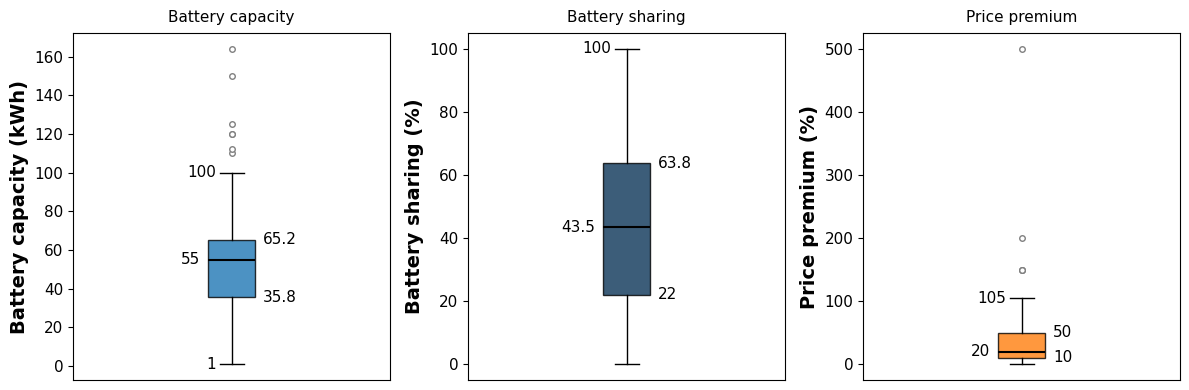

In [6]:
# 5) Distribution of key EV parameters (Figure 8)
# Visualises the empirical distributions of battery capacity, willingness-to-share, and price premia as boxplots, including numeric labels for medians, quartiles, and whiskers

battery_sharing = survey_data.battery_share_percent
battery_capacity = survey_data.battery_capacity_kwh
price_premium = df_price_premium["price_premium_percent"].to_numpy(float)

# Basic cleaning: drop NaNs and restrict to plausible ranges
battery_sharing = battery_sharing[~np.isnan(battery_sharing)]
battery_sharing = battery_sharing[(battery_sharing >= 0) & (battery_sharing <= 100)]
battery_capacity = battery_capacity[(battery_capacity > 0) & (battery_capacity <= 200)]
price_premium = price_premium[~np.isnan(price_premium)]
price_premium = price_premium[(price_premium >= 0) & (price_premium <= 500)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

# Color palette for the three boxplots
color_capacity = "#1f77b4"   # blue
color_premium  = "#ff7f0e"   # orange
color_share    = "#0b3558"   # darker blue for sharing

def set_y_limits_with_margin(ax, data, frac: float = 0.05) -> None:
    """Set y-limits with a small margin above and below the data"""
    data = np.asarray(data, float)
    data = data[~np.isnan(data)]
    if data.size == 0:
        return
    ymin = data.min()
    ymax = data.max()
    yrange = ymax - ymin
    margin = yrange * frac if yrange > 0 else max(1.0, abs(ymax) * frac)
    ax.set_ylim(ymin - margin, ymax + margin)

def format_median(value) -> str:
    """
    Format a value with at most one decimal

    - no decimal if .0
    - one decimal otherwise
    """
    v = round(float(value), 1)
    if float(v).is_integer():
        return f"{int(v)}"
    else:
        return f"{v:.1f}"

def annotate_box(ax, bp_dict, data) -> None:
    """
    Add numeric labels for median, quartiles, and whiskers to a boxplot

    - quartiles (Q1, Q3) placed to the right of the box
    - whiskers placed slightly to the left of the box
    - median placed further to the left
    """
    data = np.asarray(data, float)
    data = data[~np.isnan(data)]
    if data.size == 0:
        return
    median_val = np.median(data)
    q1, q3 = np.percentile(data, [25, 75])
    whiskers = bp_dict["whiskers"]
    w_low = np.min(whiskers[0].get_ydata())
    w_high = np.max(whiskers[1].get_ydata())
    x_center = 1.0
    x_median = x_center - 0.10
    x_whisk  = x_center - 0.05
    x_quart  = x_center + 0.10

    def add_label(x, y, val, ha):
        if np.isclose(val, 0.0):
            return
        ax.text(x, y, format_median(val), va="center", ha=ha, fontsize=11)

    add_label(x_median, median_val, median_val, ha="right")
    add_label(x_quart, q1, q1, ha="left")
    add_label(x_quart, q3, q3, ha="left")
    add_label(x_whisk, w_low, w_low, ha="right")
    add_label(x_whisk, w_high, w_high, ha="right")

# Outlier style: white circles with grey edge
flierprops = dict(
    marker="o",
    markerfacecolor="white",
    markeredgecolor="0.5",
    markersize=4,
    linestyle="none",
)

# Panel 1: Battery capacity
bp_cap = axes[0].boxplot(
    battery_capacity,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor=color_capacity, edgecolor="black", alpha=0.8),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=flierprops,
)
axes[0].set_title("Battery capacity", fontsize=11, pad=8)
axes[0].set_ylabel("Battery capacity (kWh)", fontsize=14, fontweight="bold")
set_y_limits_with_margin(axes[0], battery_capacity)
annotate_box(axes[0], bp_cap, battery_capacity)

# Panel 2: Battery sharing
bp_share = axes[1].boxplot(
    battery_sharing,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor=color_share, edgecolor="black", alpha=0.8),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=flierprops,
)
axes[1].set_title("Battery sharing", fontsize=11, pad=8)
axes[1].set_ylabel("Battery sharing (%)", fontsize=14, fontweight="bold")
set_y_limits_with_margin(axes[1], battery_sharing)
annotate_box(axes[1], bp_share, battery_sharing)

# Panel 3: Price premium
bp_prem = axes[2].boxplot(
    price_premium,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor=color_premium, edgecolor="black", alpha=0.8),
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    flierprops=flierprops,
)
axes[2].set_title("Price premium", fontsize=11, pad=8)
axes[2].set_ylabel("Price premium (%)", fontsize=14, fontweight="bold")
set_y_limits_with_margin(axes[2], price_premium)
annotate_box(axes[2], bp_prem, price_premium)

for ax in axes:
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()
plt.show()

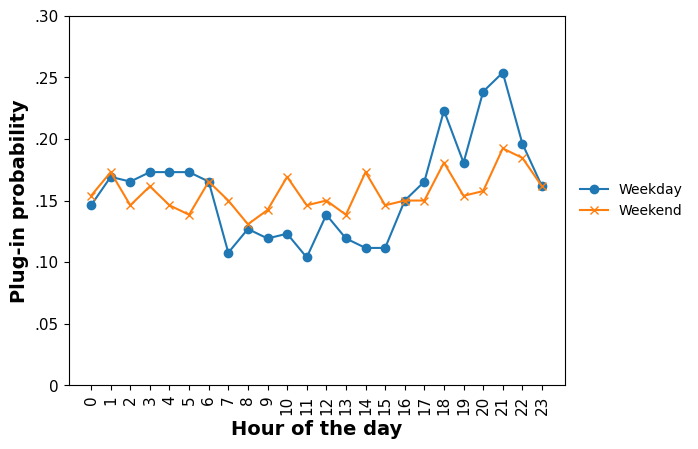

,hour,weekday_plug_in_probability,weekend_plug_in_probability
0,1,0.146154,0.153846
1,2,0.169231,0.173077
2,3,0.165385,0.146154
3,4,0.173077,0.161538
4,5,0.173077,0.146154
5,6,0.173077,0.138462
6,7,0.165385,0.165385
7,8,0.107692,0.150000
8,9,0.126923,0.130769
9,10,0.119231,0.142308


In [7]:
# 6) Empirical plug-in profiles over the day (using the working sample n = 260)
# Computes average plug-in probabilities by hour for weekdays and weekends and visualises them, and also builds a tidy table version for export or further processing

def empirical_plug_in_profile(connection_matrix: np.ndarray) -> np.ndarray:
    """Empirical plug-in probabilities for each hour of the day"""
    conn = np.asarray(connection_matrix, dtype=float)
    assert conn.ndim == 2 and conn.shape[1] == 24
    return conn.mean(axis=0)

weekday_profile = empirical_plug_in_profile(survey_data.connection_week)
weekend_profile = empirical_plug_in_profile(survey_data.connection_weekend)

hours = np.arange(24)

fig, ax = plt.subplots()
ax.plot(hours, weekday_profile, marker="o", label="Weekday")
ax.plot(hours, weekend_profile, marker="x", label="Weekend")

ax.set_xlabel("Hour of the day", fontsize=14, fontweight="bold")
ax.set_ylabel("Plug-in probability", fontsize=14, fontweight="bold")

ax.set_ylim(0, 0.30)
ax.set_xticks(hours)

# y-ticks: 0, .05, .10, ...
yticks = np.arange(0.0, 0.301, 0.05)
ax.set_yticks(yticks)
ytick_labels = ["0" if abs(t) < 1e-9 else f"{t:.2f}".lstrip("0") for t in yticks]
ax.set_yticklabels(ytick_labels)

ax.tick_params(axis="x", labelsize=11, labelrotation=90)
ax.tick_params(axis="y", labelsize=11)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    borderaxespad=0.0,
)

plt.show()

# Table of hourly plug-in probabilities for downstream use
table = pd.DataFrame(
    {
        "hour": hours.astype(int) + 1,  # 1–24 instead of 0–23
        "weekday_plug_in_probability": weekday_profile,
        "weekend_plug_in_probability": weekend_profile,
    }
)

table_rounded = table.copy()
table_rounded["weekday_plug_in_probability"] = (
    table_rounded["weekday_plug_in_probability"].round(10)
)
table_rounded["weekend_plug_in_probability"] = (
    table_rounded["weekend_plug_in_probability"].round(10)
)

display(table_rounded)

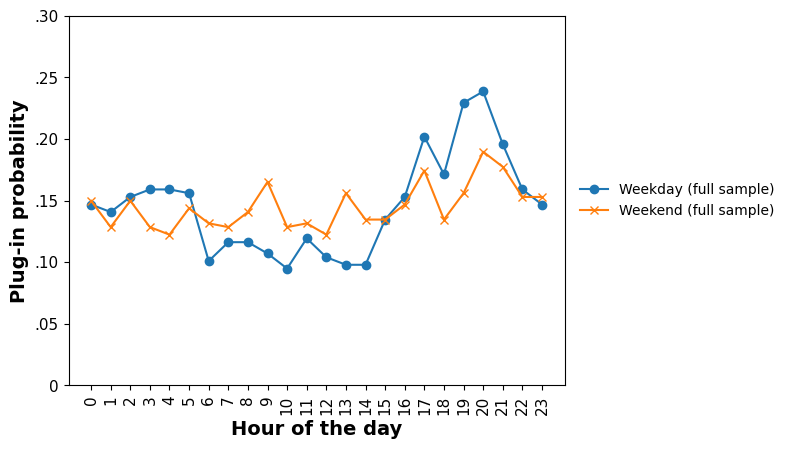

,hour,weekday_plug_in_probability,weekend_plug_in_probability
0,1,0.146789,0.149847
1,2,0.140673,0.128440
2,3,0.152905,0.149847
3,4,0.159021,0.128440
4,5,0.159021,0.122324
5,6,0.155963,0.143731
6,7,0.100917,0.131498
7,8,0.116208,0.128440
8,9,0.116208,0.140673
9,10,0.107034,0.165138


In [8]:
# 7) Empirical plug-in profiles for the full sample (full sample n = 327)
# Reconstructs hourly plug-in probabilities from all 327 EVs in the unfiltered survey sample and visualises weekday and weekend profiles with the same plot size and layout as for the working sample

RAW_SURVEY_PATH = BASE_DIR / "raw_data_surveyV2G.csv"
df_raw_full = pd.read_csv(RAW_SURVEY_PATH)

# Raw survey columns ta03_1 ... ta03_24 (weekday) and ta04_1 ... ta04_24 (weekend)
week_cols_full = [f"ta03_{h}" for h in range(1, 25)]
weekend_cols_full = [f"ta04_{h}" for h in range(1, 25)]

week_raw_full = df_raw_full[week_cols_full].to_numpy(dtype=float)
weekend_raw_full = df_raw_full[weekend_cols_full].to_numpy(dtype=float)

# Map 1/2 coding to 0/1 (0 = not connected, 1 = connected)
week01_full = np.full_like(week_raw_full, np.nan, dtype=float)
weekend01_full = np.full_like(weekend_raw_full, np.nan, dtype=float)
week01_full[week_raw_full == 2.0] = 1.0
week01_full[week_raw_full == 1.0] = 0.0
weekend01_full[weekend_raw_full == 2.0] = 1.0
weekend01_full[weekend_raw_full == 1.0] = 0.0

# Empirical plug-in probabilities for all n = 327 profiles
weekday_profile_full = np.nanmean(week01_full, axis=0)
weekend_profile_full = np.nanmean(weekend01_full, axis=0)

# Plot with the same x-axis definition as the working-sample figure (0–23)
hours_plot = np.arange(24)

fig, ax = plt.subplots()
ax.plot(hours_plot, weekday_profile_full, marker="o", label="Weekday (full sample)")
ax.plot(hours_plot, weekend_profile_full, marker="x", label="Weekend (full sample)")

ax.set_xlabel("Hour of the day", fontsize=14, fontweight="bold")
ax.set_ylabel("Plug-in probability", fontsize=14, fontweight="bold")

ax.set_ylim(0, 0.30)
ax.set_xticks(hours_plot)

yticks = np.arange(0.0, 0.301, 0.05)
ax.set_yticks(yticks)
ytick_labels = ["0" if abs(t) < 1e-9 else f"{t:.2f}".lstrip("0") for t in yticks]
ax.set_yticklabels(ytick_labels)

ax.tick_params(axis="x", labelsize=11, labelrotation=90)
ax.tick_params(axis="y", labelsize=11)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    borderaxespad=0.0,
)

plt.show()

# Build table of plug-in probabilities with hours 1–24 for export
hours_excel = np.arange(1, 25)
df_plug_in = pd.DataFrame(
    {
        "hour": hours_excel,
        "weekday_plug_in_probability": weekday_profile_full,
        "weekend_plug_in_probability": weekend_profile_full,
    }
)

df_plug_in_rounded = df_plug_in.copy()
df_plug_in_rounded["weekday_plug_in_probability"] = (
    df_plug_in_rounded["weekday_plug_in_probability"].round(10)
)
df_plug_in_rounded["weekend_plug_in_probability"] = (
    df_plug_in_rounded["weekend_plug_in_probability"].round(10)
)

display(df_plug_in_rounded)

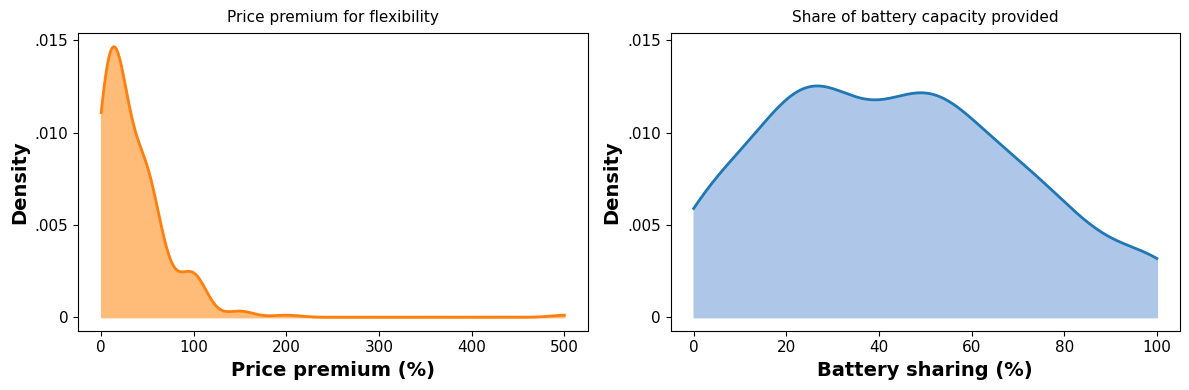

In [9]:
# 8) Flexibility preferences: price premia and available battery shares (Figure 9)
# Estimates kernel density distributions for price premia and offered battery shares and plots them side by side to illustrate flexibility preferences in the survey sample

orange_line = "#ff7f0e"
orange_fill = "#ffbb78"
blue_line   = "#1f77b4"
blue_fill   = "#aec7e8"

# Kernel density estimators for price premia and battery sharing
kde_price = gaussian_kde(price_premium)
kde_share = gaussian_kde(battery_sharing)

# x-axes
x_price = np.linspace(0, price_premium.max(), 300)
x_share = np.linspace(0, 100, 300)

y_price = kde_price(x_price)
y_share = kde_share(x_share)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

# Common y-limits across both panels for consistent scaling
y_all = np.concatenate([y_price, y_share])
y_all = y_all[~np.isnan(y_all)]
ymin = y_all.min()
ymax = y_all.max()
yrange = ymax - ymin
margin = yrange * 0.05 if yrange > 0 else max(1e-3, abs(ymax) * 0.05)
y_lower = ymin - margin
y_upper = ymax + margin

def compact_density_formatter(x, pos):
    if abs(x) < 1e-9:
        return "0"
    return f"{x:.3f}".lstrip("0")

def setup_density_axis(ax):
    ax.set_ylim(y_lower, y_upper)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_formatter(FuncFormatter(compact_density_formatter))
    ax.tick_params(axis="both", labelsize=11)

# Left panel: price premium distribution
axes[0].fill_between(x_price, y_price, color=orange_fill)
axes[0].plot(x_price, y_price, color=orange_line, linewidth=2)
axes[0].set_xlabel("Price premium (%)", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Density", fontsize=14, fontweight="bold")
axes[0].set_title("Price premium for flexibility", fontsize=11, pad=8)
setup_density_axis(axes[0])

# Right panel: available battery share distribution
axes[1].fill_between(x_share, y_share, color=blue_fill)
axes[1].plot(x_share, y_share, color=blue_line, linewidth=2)
axes[1].set_xlabel("Battery sharing (%)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Density", fontsize=14, fontweight="bold")
axes[1].set_title("Share of battery capacity provided", fontsize=11, pad=8)
setup_density_axis(axes[1])

plt.tight_layout()
plt.show()

In [10]:
# 9) Markov-chain profile from empirical connection data
# Estimates a time-inhomogeneous two-state Markov chain for EV connection status based on hourly connection matrices for weekdays and weekends and prints summary statistics for the resulting transition probabilities

@dataclass
class MarkovChainProfile:
    """
    Time-inhomogeneous two-state Markov chain for EV connection status

    States
    -------
    1 = connected, 0 = disconnected
    """

    p1: float
    transition_matrices: List[np.ndarray]

def build_markov_chain_from_connection_matrix(connection_matrix: np.ndarray) -> MarkovChainProfile:
    """
    Build a Markov chain from empirical connection data

    connection_matrix has shape (n_vehicles, 24) with 0/1 connection states
    """
    conn = np.asarray(connection_matrix, dtype=int)
    if conn.ndim != 2 or conn.shape[1] != 24:
        raise ValueError("connection_matrix must have shape (n, 24)")
    n, T = conn.shape
    p1 = (conn[:, 0] == 1).mean()
    matrices: List[np.ndarray] = []
    for t in range(T - 1):
        cur = conn[:, t]
        nxt = conn[:, t + 1]
        mask1 = cur == 1
        mask0 = cur == 0
        p11 = (nxt[mask1] == 1).mean() if mask1.any() else 0.0
        p22 = (nxt[mask0] == 0).mean() if mask0.any() else 0.0
        P = np.array(
            [
                [p11, 1.0 - p11],   # row for state 1 (connected)
                [1.0 - p22, p22],   # row for state 0 (disconnected)
            ],
            dtype=float,
        )
        matrices.append(P)
    return MarkovChainProfile(p1=p1, transition_matrices=matrices)

mc_weekday = build_markov_chain_from_connection_matrix(survey_data.connection_week)
mc_weekend = build_markov_chain_from_connection_matrix(survey_data.connection_weekend)

print("Markov-chain profile based on empirical connection data")
print("-" * 55)
print(f"Number of vehicles (weekday sample):  {survey_data.connection_week.shape[0]}")
print(f"Number of vehicles (weekend sample):  {survey_data.connection_weekend.shape[0]}")
print(f"Number of hourly transitions per day: {len(mc_weekday.transition_matrices)}")
print()
print(f"Initial plug-in probability at hour 0 (weekday): {mc_weekday.p1:.3f}")
print(f"Initial plug-in probability at hour 0 (weekend): {mc_weekend.p1:.3f}")

P_w = np.stack(mc_weekday.transition_matrices, axis=0)
P_we = np.stack(mc_weekend.transition_matrices, axis=0)

def summarize_chain(P: np.ndarray, label: str) -> None:
    """
    Print compact summary of transition probabilities over all hours

    P has shape (T-1, 2, 2) with rows [state=1, state=0]
    """
    p11 = P[:, 0, 0]
    p10 = P[:, 0, 1]
    p01 = P[:, 1, 0]
    p00 = P[:, 1, 1]
    print(f"\nSummary of hourly transition probabilities ({label})")
    print(f"  mean p(1→1) stay connected      : {p11.mean():.3f}  (min {p11.min():.3f}, max {p11.max():.3f})")
    print(f"  mean p(1→0) disconnect          : {p10.mean():.3f}  (min {p10.min():.3f}, max {p10.max():.3f})")
    print(f"  mean p(0→1) connect             : {p01.mean():.3f}  (min {p01.min():.3f}, max {p01.max():.3f})")
    print(f"  mean p(0→0) stay disconnected   : {p00.mean():.3f}  (min {p00.min():.3f}, max {p00.max():.3f})")

summarize_chain(P_w, "weekday sample")
summarize_chain(P_we, "weekend sample")

print("\nExample hourly transition matrices P_t (rows: state at t, columns: state at t+1)")
example_hours = [0, 7, 17]  # transitions 0→1, 7→8, 17→18
for h in example_hours:
    Pw_h = P_w[h]
    Pwe_h = P_we[h]
    print(f"\nHour {h:02d}→{(h+1)%24:02d}")
    print(f"  Weekday P_{h} = [[p11, p10],[p01, p00]] = [[{Pw_h[0,0]:.3f}, {Pw_h[0,1]:.3f}],[{Pw_h[1,0]:.3f}, {Pw_h[1,1]:.3f}]]")
    print(f"  Weekend P_{h} = [[p11, p10],[p01, p00]] = [[{Pwe_h[0,0]:.3f}, {Pwe_h[0,1]:.3f}],[{Pwe_h[1,0]:.3f}, {Pwe_h[1,1]:.3f}]]")

Markov-chain profile based on empirical connection data
-------------------------------------------------------
Number of vehicles (weekday sample):  260
Number of vehicles (weekend sample):  260
Number of hourly transitions per day: 23

Initial plug-in probability at hour 0 (weekday): 0.146
Initial plug-in probability at hour 0 (weekend): 0.154

Summary of hourly transition probabilities (weekday sample)
  mean p(1→1) stay connected      : 0.589  (min 0.242, max 0.867)
  mean p(1→0) disconnect          : 0.411  (min 0.133, max 0.758)
  mean p(0→1) connect             : 0.077  (min 0.028, max 0.180)
  mean p(0→0) stay disconnected   : 0.923  (min 0.820, max 0.972)

Summary of hourly transition probabilities (weekend sample)
  mean p(1→1) stay connected      : 0.621  (min 0.324, max 0.921)
  mean p(1→0) disconnect          : 0.379  (min 0.079, max 0.676)
  mean p(0→1) connect             : 0.071  (min 0.009, max 0.122)
  mean p(0→0) stay disconnected   : 0.929  (min 0.878, max 0.991)

E

In [11]:
# 10) KDE-based sampling and Monte Carlo-based hourly control potential
# Samples synthetic EV parameters from survey-based KDEs and combines them with empirically based Monte Carlo connection states to compute the hourly control potential per EV

def sample_from_kde(data: np.ndarray, n_samples: int) -> np.ndarray:
    """
    Draw samples from a kernel density estimate fitted to empirical data
    Values are clipped at zero to avoid negative capacities or percentages
    """
    x = np.asarray(data, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        raise ValueError("Cannot fit KDE to an empty dataset")
    kde = gaussian_kde(x, bw_method="scott")
    draws = kde.resample(n_samples)[0]
    draws = np.clip(draws, 0.0, None)
    return draws

def draw_ev_parameters(
    survey_data: EVSurveyData,
    n_vehicles: int,
    seed: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Sample synthetic EV parameters from survey-based KDEs

    Returns
    -------
    share_percent : array of willingness-to-share values in percent
    capacity_kwh  : array of battery capacities in kWh
    """
    rng = np.random.default_rng(seed)
    share_percent = sample_from_kde(
        survey_data.battery_share_percent,
        n_samples=n_vehicles,
    )
    capacity_kwh = sample_from_kde(
        survey_data.battery_capacity_kwh,
        n_samples=n_vehicles,
    )
    perm = rng.permutation(n_vehicles)
    return share_percent[perm], capacity_kwh[perm]

def compute_control_potential(
    share_percent: np.ndarray,
    capacity_kwh: np.ndarray,
    connection_states: np.ndarray,
    use_willingness: bool = True,
) -> np.ndarray:
    """
    Compute hourly control potential (available energy) per EV

    control[i, t] = share_fraction[i] * capacity_kwh[i] * connection_states[i, t]
    """
    share_percent = np.asarray(share_percent, float).reshape(-1, 1)
    capacity_kwh = np.asarray(capacity_kwh, float).reshape(-1, 1)
    AZ = np.asarray(connection_states, float)
    if AZ.ndim != 2 or AZ.shape[0] != share_percent.shape[0]:
        raise ValueError("connection_states must have shape (n_vehicles, 24)")
    if use_willingness:
        share_fraction = share_percent / 100.0
    else:
        share_fraction = np.ones_like(share_percent)
    return share_fraction * capacity_kwh * AZ

# Draw parameters for a large synthetic fleet (100,000 vehicles used here for faster computation; the paper uses 122 million EVs for the 2035 scenario)
n_vehicles = 100_000 # quick demo
#n_vehicles = 122_000_000 # full-scale scenario
share_demo, cap_demo = draw_ev_parameters(
    survey_data,
    n_vehicles=n_vehicles,
    seed=123,
)

# Compute control potential for the subset that matches the survey-sized fleet
n_survey = survey_data.connection_week.shape[0]
control_potential_demo = compute_control_potential(
    share_percent=share_demo[:n_survey],
    capacity_kwh=cap_demo[:n_survey],
    connection_states=survey_data.connection_week,
    use_willingness=True,
)

print("Sampled mean capacity [kWh]:", cap_demo.mean().round(1))
print("Sampled mean willingness [%]:", share_demo.mean().round(1))
print("Mean hourly control potential per EV [kWh]:", control_potential_demo.mean().round(3))
print("\nMCMC control potential demo for first 5 EVs (kWh per hour):")
print(control_potential_demo[:5, :].round(2))

Sampled mean capacity [kWh]: 52.5
Sampled mean willingness [%]: 44.0
Mean hourly control potential per EV [kWh]: 4.027

MCMC control potential demo for first 5 EVs (kWh per hour):
[[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
   1.98  1.98  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   19.28  0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.   19.28  0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    8.4   0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    8.4   0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  27.62  0.   27.62 27.62 27.62 27.62 27.62  0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.    0.   63.67  0.    0.    0.    0.    0.
   0.    0.    0.    0.    0.    0.    0.    0.    0.   63.67  0.    0.  ]]


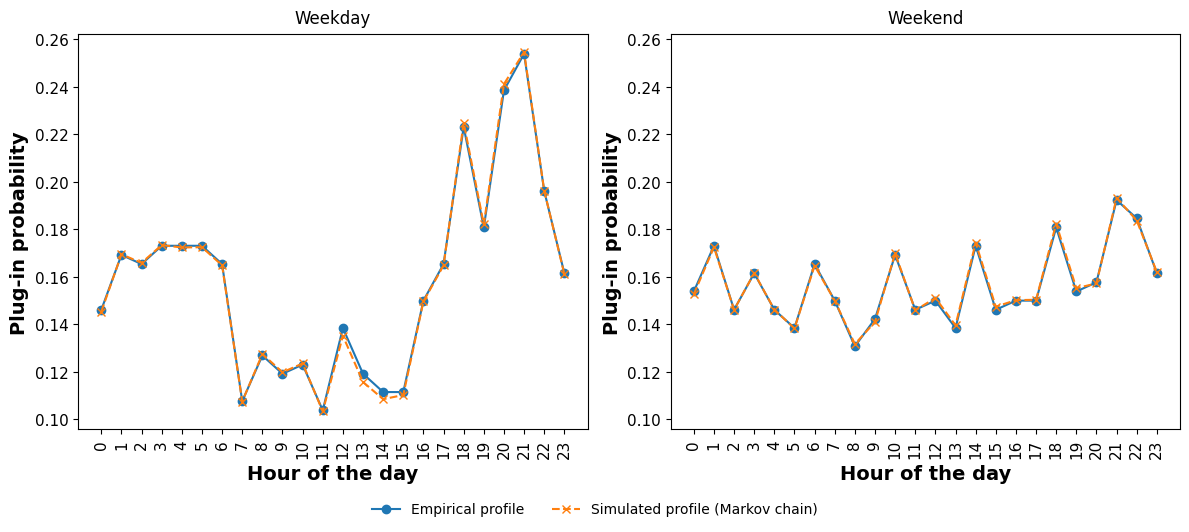

In [12]:
# 11) Simulated vs empirical plug-in profiles (weekday and weekend)
# Uses the estimated Markov chains to simulate daily connection paths for many EVs and compares the resulting plug-in profiles to the empirical weekday and weekend profiles

def sample_connection_paths(
    mc: MarkovChainProfile,
    n_vehicles: int,
    seed: int | None = None,
) -> np.ndarray:
    """
    Simulate daily connection trajectories using a time-inhomogeneous Markov chain

    Returns a matrix AZ with shape (n_vehicles, 24) containing 0/1 connection states
    """
    rng = np.random.default_rng(seed)
    T = len(mc.transition_matrices) + 1
    AZ = np.zeros((n_vehicles, T), dtype=int)
    for i in range(n_vehicles):
        state = 1 if rng.random() < mc.p1 else 0
        AZ[i, 0] = state
        for t in range(1, T):
            P = mc.transition_matrices[t - 1]
            r = rng.random()
            if state == 1:
                state = 1 if r < P[0, 0] else 0
            else:
                state = 1 if r < P[1, 0] else 0
            AZ[i, t] = state
    return AZ

# Number of simulated vehicles (100,000 used here for fast diagnostics; the Markov-chain approach can be applied to much larger fleets)
n_vehicles = 100_000 # quick demo
#n_vehicles = 122_000_000 # full-scale scenario

# Simulate weekday and weekend connection states and aggregate to hourly profiles
sim_conn_weekday = sample_connection_paths(mc_weekday, n_vehicles=n_vehicles, seed=42)
sim_conn_weekend = sample_connection_paths(mc_weekend, n_vehicles=n_vehicles, seed=43)

sim_weekday_profile = empirical_plug_in_profile(sim_conn_weekday)
sim_weekend_profile = empirical_plug_in_profile(sim_conn_weekend)

hours = np.arange(24)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Left panel: weekday
ax = axes[0]
line_emp_wd, = ax.plot(hours, weekday_profile, marker="o", label="Empirical weekday")
line_sim_wd, = ax.plot(
    hours,
    sim_weekday_profile,
    marker="x",
    linestyle="--",
    label="Simulated weekday (Markov chain)",
)
ax.set_xlabel("Hour of the day", fontsize=14, fontweight="bold")
ax.set_ylabel("Plug-in probability", fontsize=14, fontweight="bold")
ax.set_xticks(hours)
ax.tick_params(axis="x", labelsize=11, labelrotation=90)
ax.tick_params(axis="y", labelsize=11)
ax.set_title("Weekday", fontsize=12, pad=8)

# Right panel: weekend
ax2 = axes[1]
line_emp_we, = ax2.plot(hours, weekend_profile, marker="o", label="Empirical weekend")
line_sim_we, = ax2.plot(
    hours,
    sim_weekend_profile,
    marker="x",
    linestyle="--",
    label="Simulated weekend (Markov chain)",
)
ax2.set_xlabel("Hour of the day", fontsize=14, fontweight="bold")
ax2.set_ylabel("Plug-in probability", fontsize=14, fontweight="bold")
ax2.set_xticks(hours)
ax2.tick_params(axis="x", labelsize=11, labelrotation=90)
ax2.tick_params(axis="y", labelsize=11, labelleft=True)
ax2.set_title("Weekend", fontsize=12, pad=8)

# Synchronise y-axis limits across both panels
ymin = min(ax.get_ylim()[0], ax2.get_ylim()[0])
ymax = max(ax.get_ylim()[1], ax2.get_ylim()[1])
ax.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)

# Shared legend centered below both panels
legend_handles = [line_emp_wd, line_sim_wd]
legend_labels = ["Empirical profile", "Simulated profile (Markov chain)"]

fig.tight_layout(rect=(0, 0.16, 1, 1))
fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.12),
    frameon=False,
    borderaxespad=0.0,
    ncol=2,
)

plt.show()

Non-missing after parsing: capacity: 301 sharing: 296 premium: 302 
Working sample size after capacity filter: 260 
Final working sample size: 260 vehicles

Empirical plug-in probability (raw): min = 0.104, max = 0.254
Empirical plug-in probability (smoothed): min = 0.114, max = 0.232
Available battery capacity 2035 (MCMC, 122 mio EVs, raw): min = 0 GWh, max = 1 GWh
Available battery capacity 2035 (MCMC, 122 mio EVs, smoothed): min = 0 GWh, max = 1 GWh


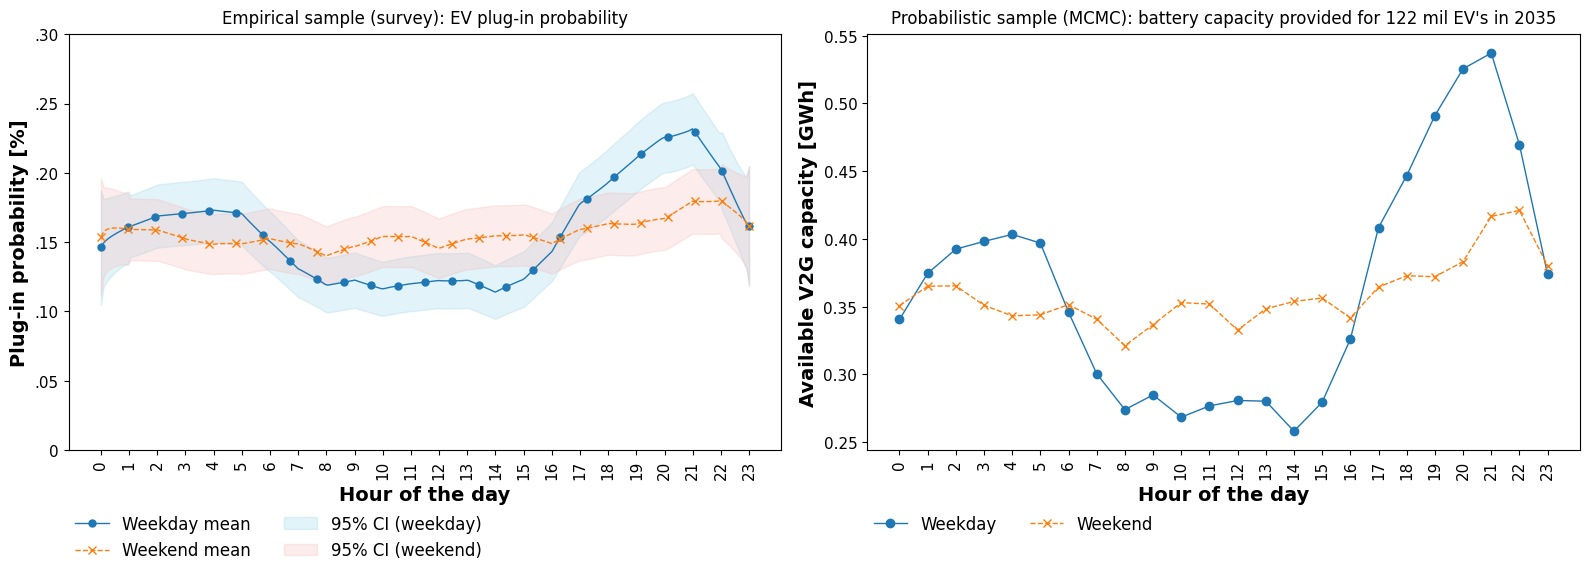

In [ ]:
# 12) Local polynomial smoothing of plug-in profiles and MCMC-based fleet control potential
# Applies local polynomial regression to empirical plug-in profiles and to simulated MCMC-based fleet-level V2G capacity for plotting and diagnostics

# --- 1) Local polynomial smoothing with CI for binary data
def lpoly_ci_binary(
    conn: np.ndarray,
    grid: np.ndarray | None = None,
    degree: int = 1,
    bandwidth: float = 2.0,
):
    """
    Local polynomial regression for binary data (0/1) with Epanechnikov kernel and 95% CI
    """
    conn = np.asarray(conn, dtype=float)
    n, T = conn.shape

    # Long format: one observation per vehicle-hour
    y = conn.ravel()
    x = np.tile(np.arange(T, dtype=float), n)

    if grid is None:
        grid = np.linspace(0.0, T - 1, 241)
    grid = np.asarray(grid, dtype=float)

    p = degree
    m = np.empty_like(grid)
    lo = np.empty_like(grid)
    hi = np.empty_like(grid)

    def kern_epan(u):
        out = 0.75 * (1.0 - u**2)
        out[np.abs(u) > 1.0] = 0.0
        return out

    for idx, x0 in enumerate(grid):
        u = (x - x0) / bandwidth
        w = kern_epan(u)
        mask = w > 0

        # Fallback if too few points in the local window
        if mask.sum() < p + 2:
            idx_sorted = np.argsort(np.abs(x - x0))
            use = idx_sorted[: max(p + 2, 10)]
            x_use = x[use]
            y_use = y[use]
            w_use = np.ones_like(y_use)
        else:
            x_use = x[mask]
            y_use = y[mask]
            w_use = w[mask]

        # Polynomial in (x - x0)
        x_c = x_use - x0
        Z = np.column_stack([x_c**d for d in range(p + 1)])

        # Weighted least squares with small ridge regularisation
        W = np.diag(w_use)
        ZWZ = Z.T @ W @ Z
        ZWy = Z.T @ W @ y_use
        reg_matrix = ZWZ + 1e-8 * np.eye(p + 1)

        beta = np.linalg.solve(reg_matrix, ZWy)
        mu = beta[0]

        # Residuals and variance estimate
        resid = y_use - Z @ beta
        df = max(1, len(y_use) - (p + 1))
        sigma2 = float(resid.T @ (W @ resid)) / df
        cov_beta = sigma2 * np.linalg.inv(reg_matrix)
        se_mu = np.sqrt(max(cov_beta[0, 0], 0.0))

        m[idx] = mu
        lo[idx] = mu - 1.96 * se_mu
        hi[idx] = mu + 1.96 * se_mu

    # Clip to [0, 1] because these are probabilities
    m = np.clip(m, 0.0, 1.0)
    lo = np.clip(lo, 0.0, 1.0)
    hi = np.clip(hi, 0.0, 1.0)
    return grid, m, lo, hi

# --- 2) Local polynomial smoothing for 1D series (no CI)
def lpoly_smooth(
    x: np.ndarray,
    y: np.ndarray,
    degree: int = 1,
    bandwidth: float = 2.0,
) -> np.ndarray:
    """
    Local polynomial regression with Epanechnikov kernel for a 1D series
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    grid = x.copy()
    p = degree
    m = np.empty_like(grid)

    def kern_epan(u):
        out = 0.75 * (1.0 - u**2)
        out[np.abs(u) > 1.0] = 0.0
        return out

    for idx, x0 in enumerate(grid):
        u = (x - x0) / bandwidth
        w = kern_epan(u)
        mask = w > 0

        if mask.sum() < p + 1:
            idx_sorted = np.argsort(np.abs(x - x0))
            use = idx_sorted[: max(p + 1, 3)]
            x_use = x[use]
            y_use = y[use]
            w_use = np.ones_like(y_use)
        else:
            x_use = x[mask]
            y_use = y[mask]
            w_use = w[mask]

        x_c = x_use - x0
        Z = np.column_stack([x_c**d for d in range(p + 1)])

        W = np.diag(w_use)
        ZWZ = Z.T @ W @ Z
        ZWy = Z.T @ W @ y_use
        reg_matrix = ZWZ + 1e-8 * np.eye(p + 1)

        beta = np.linalg.solve(reg_matrix, ZWy)
        mu = beta[0]
        m[idx] = mu

    return m

# --- 3) Prepare empirical data and smoothed plug-in profiles
survey_data = load_ev_survey_data(BASE_DIR)
weekday_conn = survey_data.connection_week
weekend_conn = survey_data.connection_weekend

grid = np.linspace(0.0, 23.0, 241)

grid_wd, wd_mean_s, wd_low_s, wd_high_s = lpoly_ci_binary(
    weekday_conn, grid=grid, degree=1, bandwidth=2
)
grid_we, we_mean_s, we_low_s, we_high_s = lpoly_ci_binary(
    weekend_conn, grid=grid, degree=1, bandwidth=2
)

hours = np.arange(24, dtype=float)

# --- 4) Simulated control potential for a synthetic fleet
# 100000 vehicles are used here only for quick tests; this downscaling leads to much smaller GWh values,
# which will look implausible if the goal is to reproduce the absolute results reported in the paper
# to match the 2035 results in the paper (full European fleet), set n_vehicles = 122000000
n_vehicles = 100000
# n_vehicles = 122000000  # 122 million EVs in 2035

share_sim, cap_sim = draw_ev_parameters(survey_data, n_vehicles=n_vehicles, seed=1)

conn_sim_weekday = sample_connection_paths(mc_weekday, n_vehicles=n_vehicles, seed=2)
conn_sim_weekend = sample_connection_paths(mc_weekend, n_vehicles=n_vehicles, seed=3)

control_weekday = compute_control_potential(
    share_percent=share_sim,
    capacity_kwh=cap_sim,
    connection_states=conn_sim_weekday,
    use_willingness=True,
)
control_weekend = compute_control_potential(
    share_percent=share_sim,
    capacity_kwh=cap_sim,
    connection_states=conn_sim_weekend,
    use_willingness=True,
)

fleet_weekday_kwh = control_weekday.sum(axis=0)
fleet_weekend_kwh = control_weekend.sum(axis=0)

fleet_weekday_gwh = fleet_weekday_kwh / 1e6
fleet_weekend_gwh = fleet_weekend_kwh / 1e6

# Smooth fleet-level profiles
fleet_weekday_gwh_s = lpoly_smooth(hours, fleet_weekday_gwh, degree=1, bandwidth=2)
fleet_weekend_gwh_s = lpoly_smooth(hours, fleet_weekend_gwh, degree=1, bandwidth=2)

# --- 5) Joint figure – layout and labels as in the original setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ci_alpha = 0.25
FOR_EMF = False  # False = normal transparency, True = EMF-safe blend with white

def blend_with_white(hexcolor, alpha):
    r, g, b = to_rgb(hexcolor)
    r2 = (1 - alpha) * 1.0 + alpha * r
    g2 = (1 - alpha) * 1.0 + alpha * g
    b2 = (1 - alpha) * 1.0 + alpha * b
    return (r2, g2, b2)

# Left plot (empirical sample): Plug-in probabilities
if FOR_EMF:
    weekday_ci = ax1.fill_between(
        grid_wd,
        wd_low_s,
        wd_high_s,
        color=blend_with_white("#8fd0e8", ci_alpha),
        alpha=1.0,
        label="95% CI (weekday)",
    )
    weekend_ci = ax1.fill_between(
        grid_we,
        we_low_s,
        we_high_s,
        color=blend_with_white("#f7b6b2", ci_alpha),
        alpha=1.0,
        label="95% CI (weekend)",
    )
else:
    weekday_ci = ax1.fill_between(
        grid_wd,
        wd_low_s,
        wd_high_s,
        color="#8fd0e8",
        alpha=ci_alpha,
        label="95% CI (weekday)",
    )
    weekend_ci = ax1.fill_between(
        grid_we,
        we_low_s,
        we_high_s,
        color="#f7b6b2",
        alpha=ci_alpha,
        label="95% CI (weekend)",
    )

weekday_line, = ax1.plot(
    grid_wd,
    wd_mean_s,
    color="#1f77b4",
    linewidth=1,
    marker="o",
    markersize=5,
    markevery=10,
    label="Weekday",
)
weekend_line, = ax1.plot(
    grid_we,
    we_mean_s,
    color="#ff7f0e",
    linewidth=1,
    linestyle="--",
    marker="x",
    markersize=6,
    markevery=10,
    label="Weekend",
)

ax1.set_xlabel("Hour of the day", fontsize=14, fontweight="bold")
ax1.set_ylabel("Plug-in probability [%]", fontsize=14, fontweight="bold")
ax1.set_xticks(hours)
ax1.set_ylim(0, 0.30)
ax1.set_title("Empirical sample (survey): EV plug-in probability", fontsize=12, pad=8)

yticks = np.arange(0.0, 0.301, 0.05)
ax1.set_yticks(yticks)
ytick_labels = []
for t in yticks:
    if np.isclose(t, 0.0):
        ytick_labels.append("0")
    else:
        ytick_labels.append(f"{t:.2f}".lstrip("0"))
ax1.set_yticklabels(ytick_labels)

ax1.tick_params(axis="x", labelsize=11, labelrotation=90)
ax1.tick_params(axis="y", labelsize=11)

ax1_legend_handles = [weekday_line, weekend_line, weekday_ci, weekend_ci]
ax1_legend_labels = [
    "Weekday mean",
    "Weekend mean",
    "95% CI (weekday)",
    "95% CI (weekend)",
]
ax1.legend(
    ax1_legend_handles,
    ax1_legend_labels,
    loc="upper left",
    bbox_to_anchor=(0.0, -0.14),
    ncol=2,
    frameon=False,
    fontsize=12,
    borderaxespad=0.0,
)

# Right plot (MCMC-based probabilistic sample): Control potential
line_wd, = ax2.plot(
    hours,
    fleet_weekday_gwh_s,
    marker="o",
    label="Weekday",
    color="#1f77b4",
    linewidth=1,
)
line_we, = ax2.plot(
    hours,
    fleet_weekend_gwh_s,
    marker="x",
    linestyle="--",
    label="Weekend",
    color="#ff7f0e",
    linewidth=1,
)

ax2.set_ylabel("Available V2G capacity [GWh]", fontsize=14, fontweight="bold")
ax2.set_xlabel("Hour of the day", fontsize=14, fontweight="bold")
ax2.set_xticks(hours)
ax2.set_xticklabels([str(int(h)) for h in hours])
ax2.tick_params(axis="x", labelsize=11, labelrotation=90)
ax2.tick_params(axis="y", labelsize=11)
ax2.set_title(
    "Probabilistic sample (MCMC): battery capacity provided for 122 mil EV's in 2035",
    fontsize=12,
    pad=8,
)

ax2_legend_handles = [line_wd, line_we]
ax2_legend_labels = ["Weekday", "Weekend"]
ax2.legend(
    ax2_legend_handles,
    ax2_legend_labels,
    loc="upper left",
    bbox_to_anchor=(0.0, -0.14),
    ncol=2,
    frameon=False,
    fontsize=12,
    borderaxespad=0.0,
)

# --- 6) Diagnostics for empirical and simulated profiles
wd_mean_raw = weekday_conn.mean(axis=0)
we_mean_raw = weekend_conn.mean(axis=0)
emp_all_raw = np.concatenate([wd_mean_raw, we_mean_raw])
emp_min_raw = emp_all_raw.min()
emp_max_raw = emp_all_raw.max()

print(
    f"\nEmpirical plug-in probability (raw): "
    f"min = {emp_min_raw:.3f}, max = {emp_max_raw:.3f}"
)

emp_all = np.concatenate([wd_mean_s, we_mean_s])
emp_min = emp_all.min()
emp_max = emp_all.max()

print(
    f"Empirical plug-in probability (smoothed): "
    f"min = {emp_min:.3f}, max = {emp_max:.3f}"
)

mcmc_all = np.concatenate([fleet_weekday_gwh, fleet_weekend_gwh])
mcmc_min = mcmc_all.min()
mcmc_max = mcmc_all.max()

print(
    f"Available battery capacity 2035 (MCMC, 122 mio EVs, raw): "
    f"min = {mcmc_min:.0f} GWh, max = {mcmc_max:.0f} GWh"
)

mcmc_all_s = np.concatenate([fleet_weekday_gwh_s, fleet_weekend_gwh_s])
mcmc_min_s = mcmc_all_s.min()
mcmc_max_s = mcmc_all_s.max()

print(
    f"Available battery capacity 2035 (MCMC, 122 mio EVs, smoothed): "
    f"min = {mcmc_min_s:.0f} GWh, max = {mcmc_max_s:.0f} GWh"
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.24, wspace=0.12)
plt.show()

In [14]:
# 13) Export empirical plug-in probabilities to GAMS .inc file for E2M2s (using the working sample n = 260)
# Builds "Par iLoadPluginProb_25.inc" from weekday and weekend plug-in profiles of the 260-EV working sample by mapping them to typical-day time slices and attaching them to EV clusters and storage technologies for all model years

BASE_DIR = Path(".").resolve()
HOUR_RES_PATH = BASE_DIR / "Par hour_resolution.inc"

# --- 1) Read hour_resolution → duration of each time slice
def read_hour_resolution(path: Path) -> dict[str, int]:
    """
    Parse Par hour_resolution.inc into a dict mapping time-slice names to their duration in hours
    """
    hour_res: dict[str, int] = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("*") or "=" not in line:
                continue
            name, val = line.split("=")
            hour_res[name.strip()] = int(float(val.strip()))
    return hour_res

hour_res = read_hour_resolution(HOUR_RES_PATH)

# time indices in the same sorted order as in the .inc file
time_slices = sorted(hour_res.keys())  # e.g. We01Aug, We01Feb, ..., Wo22Nov

# --- 2) Mapping: block code → start hour in the 24 h day
BLOCK_STARTS = {
    "01": 0,   # 6 hour block: hours 0–5
    "07": 6,   # 5 hour block: hours 6–10
    "12": 11,  # 1 hour block: hour 11
    "13": 12,  # 3 hour block: hours 12–14
    "16": 15,  # 3 hour block: hours 15–17
    "19": 18,  # 3 hour block: hours 18–20
    "22": 21,  # 3 hour block: hours 21–23
}

def block_start_and_length(time_name: str) -> tuple[int, int]:
    """
    Given a time-slice name like 'We01Aug' or 'Wo16Feb', return start hour and block length
    """
    code = time_name[2:4]  # '01', '07', '12', ...
    start = BLOCK_STARTS[code]
    length = hour_res[time_name]
    return start, length

# --- 3) Aggregation: hourly empirical profile → time-slice mean
# Input arrays weekday_profile / weekend_profile must be defined beforehand
def aggregate_empirical_plug_in(
    time_name: str,
    weekday_profile: np.ndarray,
    weekend_profile: np.ndarray,
) -> float:
    """
    Map a 24 h empirical profile to a single time-slice value by averaging over the corresponding block
    """
    if time_name.startswith("We"):
        profile = np.asarray(weekday_profile, float)
    elif time_name.startswith("Wo"):
        profile = np.asarray(weekend_profile, float)
    else:
        raise ValueError(f"Unknown day type in time '{time_name}'")

    start, length = block_start_and_length(time_name)
    segment = profile[start : start + length]
    return float(segment.mean())

# Precompute one value per time slice (independent of year and EV cluster)
val_by_time = {
    t: aggregate_empirical_plug_in(t, weekday_profile, weekend_profile)
    for t in time_slices
}

# --- 4) Definition of years and technologies
YEARS = [2023, 2030, 2035, 2040, 2045, 2050]

# EV clusters as defined in the E2M2s model
emob_clusters = [f"EmobCluster{i}" for i in range(1, 13)]

# Stationary storage technologies as in the existing Par iLoadPluginProb.inc
storage_plants = [
    "BATT_STO",
    "BATT_STO_f2030",
    "BATT_STO_f2035",
    "BATT_STO_f2040",
    "BATT_STO_f2045",
    "BATT_STO_f2050",
    "HYDR_PS",
]

# --- 5) Write .inc file – ordering as in Par iLoadPluginProb.inc
# A) EV part:    year → cluster → time
# B) Storage:    year → time    → plant
OUT_PATH = BASE_DIR / "Par iLoadPluginProb_25.inc"
lines: list[str] = []

# --- 5.1) EV clusters: empirical plug-in probability per time slice
for year in YEARS:
    for cl in emob_clusters:
        for t in time_slices:
            val = val_by_time[t]
            lines.append(f"{t}.{cl}.{year}={val}\n")

# --- 5.2) Stationary storage plants: always fully available (factor 1)
for year in YEARS:
    for t in time_slices:
        for plant in storage_plants:
            lines.append(f"{t}.{plant}.{year}=1\n")

with open(OUT_PATH, "w", encoding="utf-8") as f:
    f.writelines(lines)

print(f"Wrote empirical plug-in probabilities to: {OUT_PATH}")

Wrote empirical plug-in probabilities to: C:\Users\delic\Desktop\GitHub_V2G_E2M2s_MCMC_v2\MCMC\Par iLoadPluginProb_25.inc


In [15]:
# 14) Export scaled empirical plug-in probabilities for average scenario (using the working sample n = 260)
# Builds "Par iLoadPluginProb_61.inc" by scaling weekday and weekend profiles of the 260-EV working sample to target daily means of 56% (weekday) and 61% (weekend) and mapping them to typical-day time slices for all model years

# --- 1) Hourly plug-in profiles from the 260-EV working sample
weekday_profile_260 = empirical_plug_in_profile(survey_data.connection_week)
weekend_profile_260 = empirical_plug_in_profile(survey_data.connection_weekend)

# Current daily means of the working sample
mu_wd = float(weekday_profile_260.mean())
mu_we = float(weekend_profile_260.mean())

# Target means for Average scenario _61 (fractions, not percent)
target_wd = 0.56  # ≈ 56% on weekdays
target_we = 0.61  # ≈ 61% on weekends

# Scaling factors to reach the target daily means
scale_wd = target_wd / mu_wd if mu_wd > 0 else 1.0
scale_we = target_we / mu_we if mu_we > 0 else 1.0

weekday_profile_61 = np.clip(weekday_profile_260 * scale_wd, 0.0, 1.0)
weekend_profile_61 = np.clip(weekend_profile_260 * scale_we, 0.0, 1.0)

print("Working-sample weekday mean (before scaling):", round(mu_wd, 3))
print("Working-sample weekend mean (before scaling):", round(mu_we, 3))
print("Scale factors (weekday, weekend):", round(scale_wd, 3), round(scale_we, 3))
print("Scenario _61 weekday mean (after scaling):", round(weekday_profile_61.mean(), 3))
print("Scenario _61 weekend mean (after scaling):", round(weekend_profile_61.mean(), 3))

# --- 2) Aggregate scaled profiles to typical-day time slices
# Uses aggregate_empirical_plug_in and time_slices from Script 14
val_by_time_61 = {
    t: aggregate_empirical_plug_in(t, weekday_profile_61, weekend_profile_61)
    for t in time_slices
}

# --- 3) Write Par iLoadPluginProb_61.inc with the same structure as Par iLoadPluginProb_25.inc
# A) EV part:    year → cluster → time
# B) Storage:    year → time    → plant

OUT_PATH_61 = BASE_DIR / "Par iLoadPluginProb_61.inc"
lines_61: list[str] = []

# EV clusters: scaled plug-in probability per time slice
for year in YEARS:
    for cl in emob_clusters:
        for t in time_slices:
            val = val_by_time_61[t]
            lines_61.append(f"{t}.{cl}.{year}={val}\n")

# Stationary storage plants: always fully available (factor 1)
for year in YEARS:
    for t in time_slices:
        for plant in storage_plants:
            lines_61.append(f"{t}.{plant}.{year}=1\n")

with open(OUT_PATH_61, "w", encoding="utf-8") as f:
    f.writelines(lines_61)

print(f"Wrote scaled plug-in probabilities for Average scenario _61 to: {OUT_PATH_61}")

Working-sample weekday mean (before scaling): 0.158
Working-sample weekend mean (before scaling): 0.157
Scale factors (weekday, weekend): 3.54 3.892
Scenario _61 weekday mean (after scaling): 0.56
Scenario _61 weekend mean (after scaling): 0.61
Wrote scaled plug-in probabilities for Average scenario _61 to: C:\Users\delic\Desktop\GitHub_V2G_E2M2s_MCMC_v2\MCMC\Par iLoadPluginProb_61.inc
